In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
species_df = pd.read_csv('species_info.csv')

observation_df = pd.read_csv('observations.csv')

In [3]:
print(species_df.head()) # Understanding the data
print(species_df.dtypes)

print(observation_df.head())
print(observation_df.dtypes)

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 NaN  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN  
4                                      Wapiti Or Elk                 NaN  
category               object
scientific_name        object
common_names           object
conservation_status    object
dtype: object
            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park  

In [4]:
print(species_df.info())
print(species_df.describe()) # Null values in conservation_status just means that the null species are safe from needing conservation

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
None
              category    scientific_name        common_names  \
count             5824               5824                5824   
unique               7               5541                5504   
top     Vascular Plant  Castor canadensis  Brachythecium Moss   
freq              4470                  3                   7   

       conservation_status  
count                  191  
unique                   4  
top     Species of Concern  
freq                   161  


In [5]:
print(observation_df.info())
print(observation_df.describe()) # All data is accounted for

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB
None
       observations
count  23296.000000
mean     142.287904
std       69.890532
min        9.000000
25%       86.000000
50%      124.000000
75%      195.000000
max      321.000000


In [6]:
merged_df = pd.merge(
    species_df,
    observation_df,
    on='scientific_name',
    how='left'
)

print(merged_df.head())
print(merged_df.dtypes)
print(merged_df.describe()) # Checking the success of the merge

  category                scientific_name              common_names  \
0   Mammal  Clethrionomys gapperi gapperi  Gapper's Red-Backed Vole   
1   Mammal  Clethrionomys gapperi gapperi  Gapper's Red-Backed Vole   
2   Mammal  Clethrionomys gapperi gapperi  Gapper's Red-Backed Vole   
3   Mammal  Clethrionomys gapperi gapperi  Gapper's Red-Backed Vole   
4   Mammal                      Bos bison     American Bison, Bison   

  conservation_status                            park_name  observations  
0                 NaN                  Bryce National Park           130  
1                 NaN            Yellowstone National Park           270  
2                 NaN  Great Smoky Mountains National Park            98  
3                 NaN               Yosemite National Park           117  
4                 NaN               Yosemite National Park           128  
category               object
scientific_name        object
common_names           object
conservation_status    object
par

In [7]:
grouped_conservation = merged_df.groupby('conservation_status')['observations'].sum()
print(grouped_conservation)

conservation_status
Endangered             3513
In Recovery            2107
Species of Concern    93962
Threatened             3339
Name: observations, dtype: int64


In [8]:
mean_observations = merged_df.groupby('conservation_status')['observations'].mean()

print(mean_observations)

conservation_status
Endangered             43.912500
In Recovery            87.791667
Species of Concern    128.363388
Threatened             75.886364
Name: observations, dtype: float64


In [9]:
# ^Average obeservation per species within each conservation status

In [10]:
grouped_parks = merged_df.groupby('park_name')['observations'].sum()
print(grouped_parks)

park_name
Bryce National Park                     633291
Great Smoky Mountains National Park     474863
Yellowstone National Park              1587641
Yosemite National Park                  949452
Name: observations, dtype: int64


In [11]:
park_species = merged_df.groupby('park_name')['scientific_name'].nunique()

print(park_species)

park_name
Bryce National Park                    5541
Great Smoky Mountains National Park    5541
Yellowstone National Park              5541
Yosemite National Park                 5541
Name: scientific_name, dtype: int64


In [12]:
at_risk = ['Endangered', 'Species of Concern', 'Threatened']

merged_df['is_at_risk'] = merged_df['conservation_status'].isin(at_risk)

at_risk_species = (
    merged_df[merged_df['is_at_risk']]
    .groupby('park_name')['scientific_name']
    .nunique()
)

park_risk = (at_risk_species / park_species).sort_values()
print(park_risk) # These values show that the data question I was trying to answer is the wrong one. The data at hand can not answer what I want. So I'll ask a different question.  

park_name
Bryce National Park                    0.031763
Great Smoky Mountains National Park    0.031763
Yellowstone National Park              0.031763
Yosemite National Park                 0.031763
Name: scientific_name, dtype: float64


In [13]:
endangered_species = merged_df[merged_df['conservation_status'].str.strip().str.lower() == 'endangered'] # ensuring no case issues

print(endangered_species)

print(len(endangered_species)) # There is 80 rows endanered species 

        category          scientific_name                      common_names  \
44        Mammal              Canis lupus                         Gray Wolf   
45        Mammal              Canis lupus                         Gray Wolf   
46        Mammal              Canis lupus                         Gray Wolf   
47        Mammal              Canis lupus                         Gray Wolf   
48        Mammal              Canis lupus                         Gray Wolf   
...          ...                      ...                               ...   
20007       Bird  Gymnogyps californianus                 California Condor   
20460  Amphibian             Rana sierrae  Sierra Nevada Yellow-Legged Frog   
20461  Amphibian             Rana sierrae  Sierra Nevada Yellow-Legged Frog   
20462  Amphibian             Rana sierrae  Sierra Nevada Yellow-Legged Frog   
20463  Amphibian             Rana sierrae  Sierra Nevada Yellow-Legged Frog   

      conservation_status                          

In [14]:
at_risk_obs = (
    merged_df[merged_df['is_at_risk']]
    .groupby('park_name')['observations']
    .sum()
)

park_risk_obs_ratio = (at_risk_obs / grouped_parks).sort_values()

print(park_risk_obs_ratio) # This question is more along the lines of park at-risk observation intensity. It still shows which park is potentially more dangerous, yet statictically soundly so. 

park_name
Great Smoky Mountains National Park    0.026467
Yellowstone National Park              0.027521
Yosemite National Park                 0.027733
Bryce National Park                    0.028772
Name: observations, dtype: float64


In [15]:
total_by_category = species_df.groupby('category')['scientific_name'].nunique()

endangered_by_category = (
    species_df[species_df['conservation_status'] == 'Endangered'] # Kept the uppercase 'E' because upon csv inspection that was used strictly. 
    .groupby('category')['scientific_name']
    .nunique()
)

endangered_ratio = (endangered_by_category / total_by_category).sort_values().fillna(0)


print(endangered_ratio)

category
Vascular Plant       0.000235
Bird                 0.008197
Amphibian            0.012658
Fish                 0.024000
Mammal               0.034091
Nonvascular Plant    0.000000
Reptile              0.000000
Name: scientific_name, dtype: float64


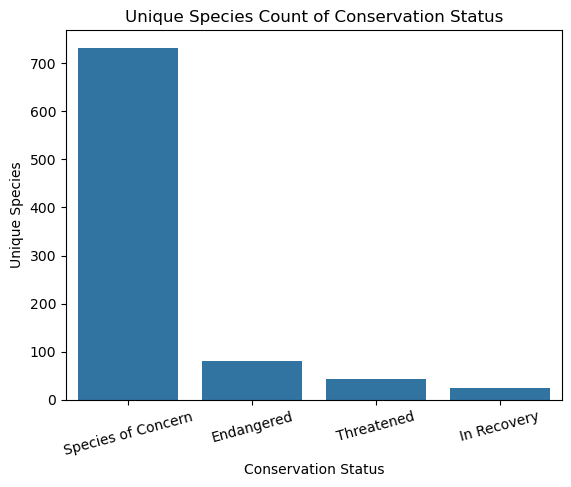

<Figure size 640x480 with 0 Axes>

In [16]:
sns.countplot(data=merged_df, x='conservation_status')
plt.xlabel('Conservation Status')
plt.xticks(rotation=15, fontsize=10)
plt.ylabel('Unique Species')
plt.title('Unique Species Count of Conservation Status')

plt.savefig('Biodiversity_Unique.png', dpi=300, bbox_inches='tight')
plt.show()
plt.clf()


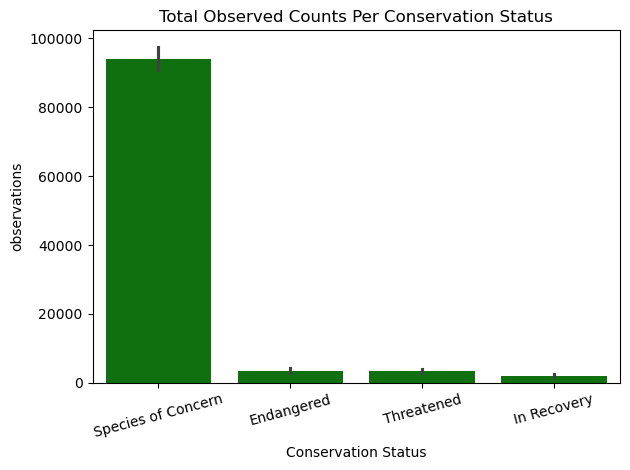

<Figure size 640x480 with 0 Axes>

In [17]:
sns.barplot(
    data = merged_df,
    x = 'conservation_status',
    y = 'observations', 
    estimator=sum,
    color='green'
)
plt.xticks(rotation=15)
plt.xlabel('Conservation Status')
plt.title('Total Observed Counts Per Conservation Status')
plt.tight_layout()

plt.savefig('Biodiversity_Total.png', dpi=300, bbox_inches='tight')
plt.show()
plt.clf()

In [18]:
# We can clearly see that there is a large porportion of life that is not endangered, yet endangered has more counts amongst the last two columns.

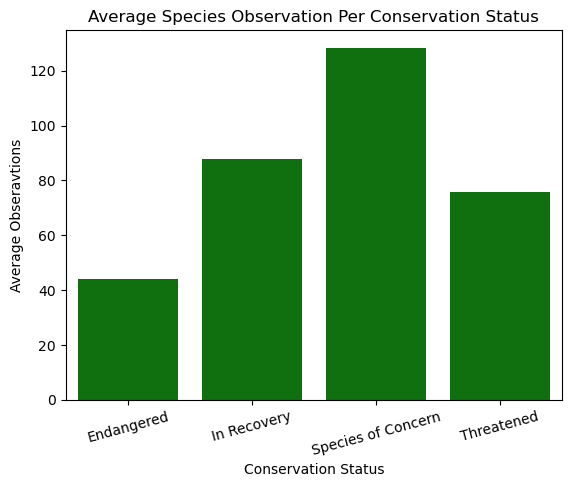

<Figure size 640x480 with 0 Axes>

In [19]:
sns.barplot(
    x=mean_observations.index,
    y=mean_observations.values,
    color='green'
)

plt.xticks(rotation=15)
plt.xlabel('Conservation Status')
plt.ylabel('Average Obseravtions')
plt.title('Average Species Observation Per Conservation Status')

plt.savefig('Biodiversity_Average.png', dpi=300, bbox_inches='tight')
plt.show()
plt.clf()

In [20]:
# Despite endangered having a higher .sum() value than 2 columns, endangered species on average are spotted less often. That metric aligns with their status of being endangered. 

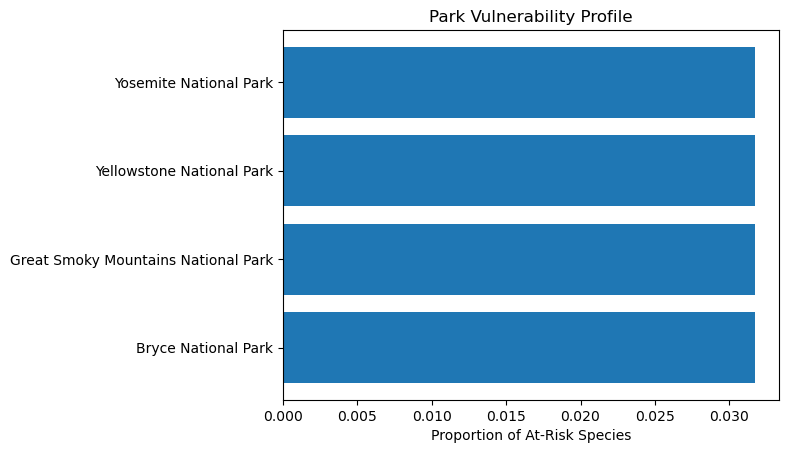

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure() # This plot was an attempt to plot park risk though the data and visualization did not answer the question clearly. Yet, I'm leaving it in the code just as a reminder. 
plt.barh(park_risk.index, park_risk.values)
plt.xlabel('Proportion of At-Risk Species')
plt.title('Park Vulnerability Profile')
plt.show()
plt.clf()

